In [ ]:
# ============================================================
# IMPORTS E CONFIGURAÇÃO
# ------------------------------------------------------------
# Projeto : Risco de abandono escolar em Roraima
# Versão  : v1 (smoke test → temporal)
# Fonte   : base_longitudinal_rr_2019_2025.parquet
# ============================================================
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
)
from sklearn.ensemble import (
    RandomForestRegressor, HistGradientBoostingRegressor,
)
from sklearn.linear_model import Ridge

# ============================================================
# CONFIGURAÇÃO GERAL
# ============================================================
RANDOM_STATE = 1
np.random.seed(RANDOM_STATE)

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')
warnings.filterwarnings('ignore', category=UserWarning, module='openpyxl')

# ============================================================
# CAMINHOS
# ============================================================
CWD  = Path.cwd()
BASE = CWD.parent if CWD.name == 'notebooks' else CWD

DADOS      = BASE / 'dados'
PROCESSADO = DADOS / 'processado'
BASE_LONG  = PROCESSADO / 'base_longitudinal_rr_2019_2025.parquet'

# ============================================================
# PARÂMETROS DO EXPERIMENTO
# ------------------------------------------------------------
# ANOS_ALVO_ATIVOS: quais ANO_ALVO entram no experimento.
#   1 ano  → split aleatório (smoke test)
#   >1 ano → split temporal (treino / validação / teste)
# Descomente os que quiser usar. O primeiro é o padrão atual.
# ============================================================
ANOS_ALVO_ATIVOS = [
    2025,
    2024,
    2023,
    2022,
    2021,
    2020,
   
]

# TARGET_NOME: qual etapa prever.
#   'FUN_AF' → anos finais do fundamental (alvo: ABANDONO_FUN_AF_T1)
#   'MED'    → ensino médio            (alvo: ABANDONO_MED_T1)
TARGET_NOME = 'FUN_AF'

# Universo: apenas escolas da rede pública
APENAS_PUBLICAS = True

# Limite mínimo de não-nulos para manter uma coluna
MIN_COBERTURA = 0.30

# ============================================================
# MAPAS DE TARGET
# ============================================================
TARGET_MAP = {
    'FUN_AF': 'ABANDONO_FUN_AF_T1',
    'MED'   : 'ABANDONO_MED_T1',
}
# Alvos irmãos — mesmo período (t+1), mas outra etapa.
# Usar como feature vazaria o futuro. São sempre removidos.
ALVOS_IRMAOS = [
    'ABANDONO_FUN_T1',
    'ABANDONO_FUN_AF_T1',
    'ABANDONO_MED_T1',
]

TARGET = TARGET_MAP[TARGET_NOME]
SIBLINGS = [a for a in ALVOS_IRMAOS if a != TARGET]

print('BASE       :', BASE)
print('Base long. :', BASE_LONG, '→', BASE_LONG.exists())
print('TARGET     :', TARGET)
print('Anos alvo  :', ANOS_ALVO_ATIVOS)
print('Irmãos drop:', SIBLINGS)

BASE       : c:\Users\gusta\Documents\Projeto da Gabi\teste censo completo
Base long. : c:\Users\gusta\Documents\Projeto da Gabi\teste censo completo\dados\processado\base_longitudinal_rr_2019_2025.parquet → True
TARGET     : ABANDONO_FUN_AF_T1
Anos alvo  : [2025, 2024, 2023, 2022, 2021, 2020]
Irmãos drop: ['ABANDONO_FUN_T1', 'ABANDONO_MED_T1']


In [20]:
# ============================================================
# CARREGAMENTO E FILTRO
# ============================================================
df = pd.read_parquet(BASE_LONG)
print(f'Base completa : {df.shape}')

# 1) Filtrar anos-alvo escolhidos
df = df[df['ANO_ALVO'].isin(ANOS_ALVO_ATIVOS)].copy()
print(f'Após anos    : {df.shape}')

# 2) Apenas rede pública
if APENAS_PUBLICAS:
    df = df[df['REDE_PUBLICA'] == 1].copy()
    print(f'Após pública : {df.shape}')

# 3) Apenas escolas que têm o alvo não-nulo
df = df[df[TARGET].notna()].copy()
print(f'Após alvo    : {df.shape}')

# Panorama rápido
print('\nDistribuição do alvo por ANO_ALVO:')
print(df.groupby('ANO_ALVO')[TARGET].agg(['count','mean','std','max']).round(3))
print(f'\nDistribuição do alvo (global):')
print(df[TARGET].describe().round(3))
print(f'\nZeros no alvo: {(df[TARGET]==0).sum():,} ({(df[TARGET]==0).mean()*100:.1f}%)')

Base completa : (6054, 59)
Após anos    : (5094, 59)
Após pública : (4855, 59)
Após alvo    : (1419, 59)

Distribuição do alvo por ANO_ALVO:
          count   mean    std   max
ANO_ALVO                           
2020        237  1.043   2.66  20.7
2021        233  3.123  4.808  23.5
2022        235  5.217    6.0  31.8
2023        232  3.147  4.515  26.5
2024        239   2.76  3.762  19.4
2025        243  2.542  4.202  25.0

Distribuição do alvo (global):
count    1419.0
mean      2.966
std       4.595
min         0.0
25%         0.0
50%         1.0
75%         4.0
max        31.8
Name: ABANDONO_FUN_AF_T1, dtype: Float64

Zeros no alvo: 587 (41.4%)


In [21]:
# ============================================================
# LIMPEZA
# ------------------------------------------------------------
# Remove:
#   - IDs, nomes, chaves
#   - colunas de ano (usadas no split, não como feature)
#   - alvos irmãos (leakage direto)
#   - o próprio TARGET (vai virar y)
#   - colunas com cobertura < MIN_COBERTURA
# ============================================================
DROP_IDS = [
    'CO_ENTIDADE', 'NO_ENTIDADE',
    'NO_MUNICIPIO',
    'ANO',
]
DROP_ANOS = ['ANO_ALVO']
DROP_LEAK = SIBLINGS + [TARGET]   # ← inclui o próprio alvo

drop_candidatos = DROP_IDS + DROP_ANOS + DROP_LEAK
drop_candidatos = [c for c in drop_candidatos if c in df.columns]

df_model = df.drop(columns=drop_candidatos).copy()
print(f'Colunas antes        : {df.shape[1]}')
print(f'Colunas removidas    : {len(drop_candidatos)} → {drop_candidatos}')
print(f'Colunas após drop    : {df_model.shape[1]}')

# --- Cobertura: remover colunas muito vazias
cobertura = df_model.notna().mean()
colunas_remover = cobertura[cobertura < MIN_COBERTURA].index.tolist()
print(f'\nRemovendo {len(colunas_remover)} colunas com cobertura < {MIN_COBERTURA:.0%}:')
for c in colunas_remover:
    print(f'  {c:<28} cobertura = {cobertura[c]:.1%}')
df_model = df_model.drop(columns=colunas_remover)

# --- X e y
# ATENÇÃO: agora o alvo vem direto de df, alinhado pelo MESMO índice
X = df_model.copy()
y = df.loc[df_model.index, TARGET].copy()   # ← usa df_model.index

# --- Separação por tipo — FEITA DEPOIS de drop do TARGET
num_cols = X.select_dtypes(include='number').columns.tolist()
cat_cols = X.select_dtypes(include=['string', 'object']).columns.tolist()

# CO_MUNICIPIO como categórica
if 'CO_MUNICIPIO' in num_cols:
    num_cols.remove('CO_MUNICIPIO')
if 'CO_MUNICIPIO' in X.columns and 'CO_MUNICIPIO' not in cat_cols:
    cat_cols.append('CO_MUNICIPIO')

print(f'\nNuméricas  ({len(num_cols)}): {num_cols}')
print(f'Categóricas ({len(cat_cols)}): {cat_cols}')

print(f'\nX: {X.shape}   y: {y.shape}')
print(f'Alvo ainda em X? {"SIM" if TARGET in X.columns else "não"}')
print(f'Índices alinhados? {X.index.equals(y.index)}')

Colunas antes        : 59
Colunas removidas    : 8 → ['CO_ENTIDADE', 'NO_ENTIDADE', 'NO_MUNICIPIO', 'ANO', 'ANO_ALVO', 'ABANDONO_FUN_T1', 'ABANDONO_MED_T1', 'ABANDONO_FUN_AF_T1']
Colunas após drop    : 51

Removendo 0 colunas com cobertura < 30%:

Numéricas  (48): ['REDE_PUBLICA', 'DISP_ATU', 'DISP_TDI', 'DISP_IED', 'DISP_REND', 'ATU_FUN_TOTAL', 'ATU_FUN_AI', 'ATU_FUN_AF', 'ATU_MED_TOTAL', 'TDI_FUN_TOTAL', 'TDI_FUN_AI', 'TDI_FUN_AF', 'TDI_MED_TOTAL', 'IED_FUN_N1', 'IED_FUN_N2', 'IED_FUN_N3', 'IED_FUN_N4', 'IED_FUN_N5', 'IED_FUN_N6', 'IED_FUN_ALTO', 'IED_MED_N1', 'IED_MED_N2', 'IED_MED_N3', 'IED_MED_N4', 'IED_MED_N5', 'IED_MED_N6', 'IED_MED_ALTO', 'APROVACAO_FUN', 'APROVACAO_FUN_AI', 'APROVACAO_FUN_AF', 'APROVACAO_MED', 'REPROVACAO_FUN', 'REPROVACAO_FUN_AI', 'REPROVACAO_FUN_AF', 'REPROVACAO_MED', 'ABANDONO_FUN', 'ABANDONO_FUN_AI', 'ABANDONO_FUN_AF', 'ABANDONO_MED', 'ABANDONO_FUN_LAG1', 'ABANDONO_FUN_AF_LAG1', 'ABANDONO_MED_LAG1', 'TDI_FUN_AF_DELTA1', 'TDI_MED_TOTAL_DELTA1', 'ATU_FUN_AF_

In [22]:
# ============================================================
# PRÉ-PROCESSAMENTO
# ------------------------------------------------------------
# Numéricas    : mediana (robusta a outliers) → standard scaler
# Categóricas  : 'Missing' → one-hot (handle_unknown='ignore')
# ============================================================
num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler' , StandardScaler()),
])

cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
    ('onehot' , OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ('num', num_pipe, num_cols),
    ('cat', cat_pipe, cat_cols),
])

print('Preprocessor pronto.')
print(f'  → num pipeline sobre {len(num_cols)} colunas')
print(f'  → cat pipeline sobre {len(cat_cols)} colunas')

Preprocessor pronto.
  → num pipeline sobre 48 colunas
  → cat pipeline sobre 3 colunas


In [23]:
# ============================================================
# SPLIT
# ------------------------------------------------------------
# Se ANOS_ALVO_ATIVOS tem 1 ano → split aleatório (smoke test)
# Se tem >1 ano              → split temporal por ANO_ALVO
# ============================================================
if len(ANOS_ALVO_ATIVOS) == 1:
    print('Modo: split aleatório (1 ano)')
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.20, random_state=RANDOM_STATE,
    )
    X_val, y_val = None, None
else:
    print('Modo: split temporal por ANO_ALVO')
    anos_ord = sorted(ANOS_ALVO_ATIVOS)
    ano_teste = anos_ord[-1]
    ano_val   = anos_ord[-2]
    anos_treino = anos_ord[:-2]

    mask_treino = df.loc[X.index, 'ANO_ALVO'].isin(anos_treino)
    mask_val    = df.loc[X.index, 'ANO_ALVO'] == ano_val
    mask_teste  = df.loc[X.index, 'ANO_ALVO'] == ano_teste

    X_train, y_train = X[mask_treino], y[mask_treino]
    X_val,   y_val   = X[mask_val],    y[mask_val]
    X_test,  y_test  = X[mask_teste],  y[mask_teste]

    print(f'  Treino   ANO_ALVO ∈ {anos_treino}  → {X_train.shape}')
    print(f'  Validação ANO_ALVO = {ano_val}        → {X_val.shape}')
    print(f'  Teste     ANO_ALVO = {ano_teste}        → {X_test.shape}')

print(f'\nTreino: {X_train.shape} | Teste: {X_test.shape}')
print(f'Média alvo (treino): {y_train.mean():.3f} | (teste): {y_test.mean():.3f}')

# ============================================================
# MODELOS
# ============================================================
modelos = {
    'Ridge'                : Ridge(alpha=1.0, random_state=RANDOM_STATE),
    'RandomForest'         : RandomForestRegressor(
        n_estimators=300, max_depth=10, min_samples_leaf=3,
        random_state=RANDOM_STATE, n_jobs=-1,
    ),
    'HistGradientBoosting' : HistGradientBoostingRegressor(
        max_iter=300, learning_rate=0.05, max_depth=6,
        random_state=RANDOM_STATE,
    ),
}

# ============================================================
# TREINO + AVALIAÇÃO
# ============================================================
resultados = {}
pipes = {}

for nome, modelo in modelos.items():
    pipe = Pipeline([('pre', preprocessor), ('model', modelo)])
    pipe.fit(X_train, y_train)
    pipes[nome] = pipe

    resultados[nome] = {}   # ← inicializa SEMPRE

    # Avalia em validação se houver
    if X_val is not None:
        pred_val = pipe.predict(X_val)
        resultados[nome].update({
            'MAE_val' : mean_absolute_error(y_val, pred_val),
            'RMSE_val': np.sqrt(mean_squared_error(y_val, pred_val)),
            'R2_val'  : r2_score(y_val, pred_val),
        })

    # Avalia no teste
    pred = pipe.predict(X_test)
    resultados[nome].update({
        'MAE_teste' : mean_absolute_error(y_test, pred),
        'RMSE_teste': np.sqrt(mean_squared_error(y_test, pred)),
        'R2_teste'  : r2_score(y_test, pred),
    })

res = pd.DataFrame(resultados).T.round(3)
print('\n=== Resultados ===')
print(res.to_string())

Modo: split temporal por ANO_ALVO
  Treino   ANO_ALVO ∈ [2020, 2021, 2022, 2023]  → (937, 51)
  Validação ANO_ALVO = 2024        → (239, 51)
  Teste     ANO_ALVO = 2025        → (243, 51)

Treino: (937, 51) | Teste: (243, 51)
Média alvo (treino): 3.128 | (teste): 2.542

=== Resultados ===
                      MAE_val  RMSE_val  R2_val  MAE_teste  RMSE_teste  R2_teste
Ridge                   2.964     3.756  -0.001      2.885       3.848     0.158
RandomForest            2.988     3.898  -0.078      2.918       3.840     0.162
HistGradientBoosting    3.049     3.991  -0.131      3.142       4.219    -0.012


=== Top 20 — RandomForestRegressor ===
 1. TDI_FUN_TOTAL                    16.90%
 2. ABANDONO_FUN_AF_DELTA1            5.26%
 3. TDI_FUN_AF_DELTA1                 5.25%
 4. TDI_MED_TOTAL                     5.17%
 5. TDI_FUN_AF                        4.67%
 6. IED_FUN_N1                        4.34%
 7. ATU_FUN_AF_DELTA1                 3.95%
 8. ABANDONO_FUN_AF_LAG1              3.43%
 9. IED_FUN_N2                        2.68%
10. REPROVACAO_FUN_AF                 2.61%
11. ATU_FUN_AF                        2.55%
12. ATU_FUN_TOTAL                     2.49%
13. APROVACAO_FUN                     2.49%
14. TDI_FUN_AI                        2.45%
15. ATU_MED_TOTAL_DELTA1              2.43%
16. IED_FUN_N3                        2.31%
17. ABANDONO_FUN                      2.23%
18. ABANDONO_FUN_LAG1                 2.20%
19. CO_MUNICIPIO                      2.00%
20. ABANDONO_MED_LAG1                 1.95%


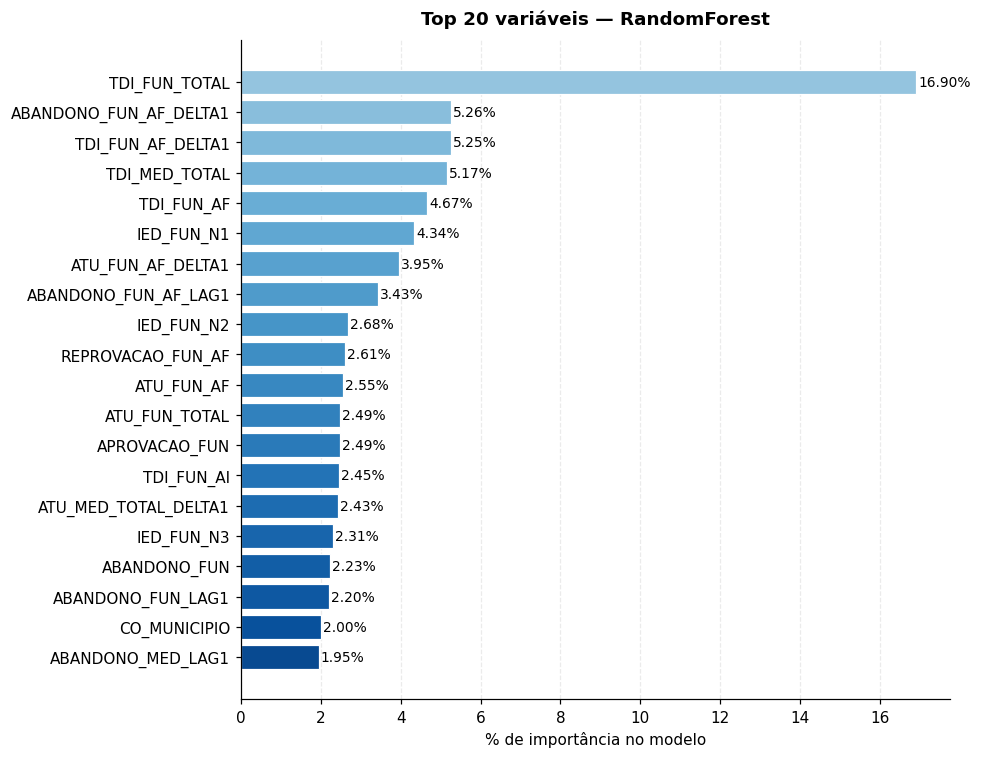

In [24]:
# ============================================================
# IMPORTÂNCIA DE VARIÁVEIS
# ============================================================
rf_pipe  = pipes['RandomForest']
rf_model = rf_pipe.named_steps['model']

feat_names   = rf_pipe.named_steps['pre'].get_feature_names_out()
importancias = pd.Series(rf_model.feature_importances_, index=feat_names)

def nome_original(nome):
    if nome.startswith('num__'):
        return nome[5:]
    if nome.startswith('cat__'):
        resto = nome[5:]
        for col in cat_cols:
            if resto == col or resto.startswith(col + '_'):
                return col
    return nome

imp_agrupada = (
    importancias
    .groupby(nome_original)
    .sum()
    .sort_values(ascending=False)
)

TOP_N = 20
tabela = imp_agrupada.head(TOP_N).to_frame('importancia')
tabela['% do total'] = (tabela['importancia'] / imp_agrupada.sum() * 100).round(2)

print(f'=== Top {TOP_N} — RandomForestRegressor ===')
for i, (var, row) in enumerate(tabela.iterrows(), 1):
    print(f'{i:>2}. {var:<30} {row["% do total"]:>7.2f}%')

# Gráfico
fig, ax = plt.subplots(figsize=(9, 7), dpi=110)
cores = plt.cm.Blues(np.linspace(0.4, 0.9, TOP_N))[::-1]
ax.barh(tabela.index[::-1], tabela['% do total'][::-1],
        color=cores, edgecolor='white', linewidth=0.8)
for bar, val in zip(ax.patches, tabela['% do total'][::-1]):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}%', va='center', fontsize=9)
ax.set_xlabel('% de importância no modelo')
ax.set_title(f'Top {TOP_N} variáveis — RandomForest', fontweight='bold', pad=10)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='x', alpha=0.25, linestyle='--')
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()